In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from utils import load_data

X_train, X_test, y_train, y_test = load_data()

In [ ]:
# 1. Label Encoding 
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()

X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

for col in categorical_cols:
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col]  = le.transform(X_test[col])


C:\Users\shrad\AppData\Local\Temp\ipykernel_35724\3361330096.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [ ]:
# 2. Handle class imbalance
# XGBoost uses scale_pos_weight instead of class_weight.
# Formula: count of negative class / count of positive class
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}  (neg={neg}, pos={pos})")

scale_pos_weight: 5.19  (neg=986, pos=190)


In [ ]:
# 3. Boosting rounds experiment 
# Unlike Random Forest where more trees always help (up to a point),
# in boosting, too many rounds causes overfitting because each new
# tree is specifically fitting residuals including noisy ones.
# eval_set lets us track train and test AUC at every boosting round.

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=30,   # stop if test AUC doesn't improve for 30 rounds
    random_state=42,
    verbosity=0
)

xgb.fit(
    X_train_enc, y_train,
    eval_set=[(X_train_enc, y_train), (X_test_enc, y_test)],
    verbose=False
)

# Retrieve per-round AUC scores
results     = xgb.evals_result()
train_aucs  = results["validation_0"]["auc"]
test_aucs   = results["validation_1"]["auc"]
best_round  = xgb.best_iteration

print(f"\nBest boosting round  : {best_round}")
print(f"Best Test AUC        : {max(test_aucs):.4f}")
print(f"Train AUC at best    : {train_aucs[best_round]:.4f}")
print(f"Overfitting gap      : {train_aucs[best_round] - test_aucs[best_round]:.4f}")



Best boosting round  : 34
Best Test AUC        : 0.7846
Train AUC at best    : 0.9502
Overfitting gap      : 0.1655


In [ ]:
# 4. Learning rate experiment 
# Lower learning rate = each tree contributes less = needs more trees
# but converges to a better solution
print("\n── Learning rate comparison ──")
lr_results = {}
lr_values  = [0.001, 0.01, 0.05, 0.1, 0.3]

for lr in lr_values:
    xgb_lr = XGBClassifier(
        n_estimators=300,
        learning_rate=lr,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=0
    )
    xgb_lr.fit(X_train_enc, y_train)
    train_auc = roc_auc_score(y_train, xgb_lr.predict_proba(X_train_enc)[:, 1])
    test_auc  = roc_auc_score(y_test,  xgb_lr.predict_proba(X_test_enc)[:, 1])
    lr_results[lr] = {"train": train_auc, "test": test_auc}
    print(f"lr={lr:<6} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f} | Gap: {train_auc - test_auc:.4f}")


── Learning rate comparison ──
lr=0.001  | Train AUC: 0.9123 | Test AUC: 0.7623 | Gap: 0.1500
lr=0.01   | Train AUC: 0.9769 | Test AUC: 0.7897 | Gap: 0.1872
lr=0.05   | Train AUC: 1.0000 | Test AUC: 0.7942 | Gap: 0.2058
lr=0.1    | Train AUC: 1.0000 | Test AUC: 0.7810 | Gap: 0.2190
lr=0.3    | Train AUC: 1.0000 | Test AUC: 0.7659 | Gap: 0.2341


In [ ]:
# 5. Final evaluation
y_pred       = xgb.predict(X_test_enc)
y_pred_proba = xgb.predict_proba(X_test_enc)[:, 1]

print(f"\n── XGBoost Final Results ──")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")


── XGBoost Final Results ──
              precision    recall  f1-score   support

          No       0.92      0.86      0.89       247
         Yes       0.46      0.62      0.53        47

    accuracy                           0.82       294
   macro avg       0.69      0.74      0.71       294
weighted avg       0.85      0.82      0.83       294

AUC: 0.7846


In [ ]:
# 6. Feature importances 
# XGBoost gives three types of importance:
# weight      - how many times a feature was used in splits
# gain        - average improvement in loss when that feature is used (most reliable)
# cover       - average number of samples affected by splits on that feature
importance_gain   = xgb.get_booster().get_score(importance_type="gain")
importance_weight = xgb.get_booster().get_score(importance_type="weight")

imp_gain_series   = pd.Series(importance_gain).sort_values(ascending=False).head(15)
imp_weight_series = pd.Series(importance_weight).sort_values(ascending=False).head(15)

print("\nTop 10 features by GAIN (most reliable):")
print(imp_gain_series.head(10))


Top 10 features by GAIN (most reliable):
OverTime                   31.552826
JobLevel                   28.990602
YearsAtCompany             26.093302
StockOptionLevel           24.320219
YearsWithCurrManager       21.878340
TotalWorkingYears          20.385445
MonthlyIncome              17.431845
NumCompaniesWorked         16.885912
EnvironmentSatisfaction    16.482777
JobRole                    16.137451
dtype: float64


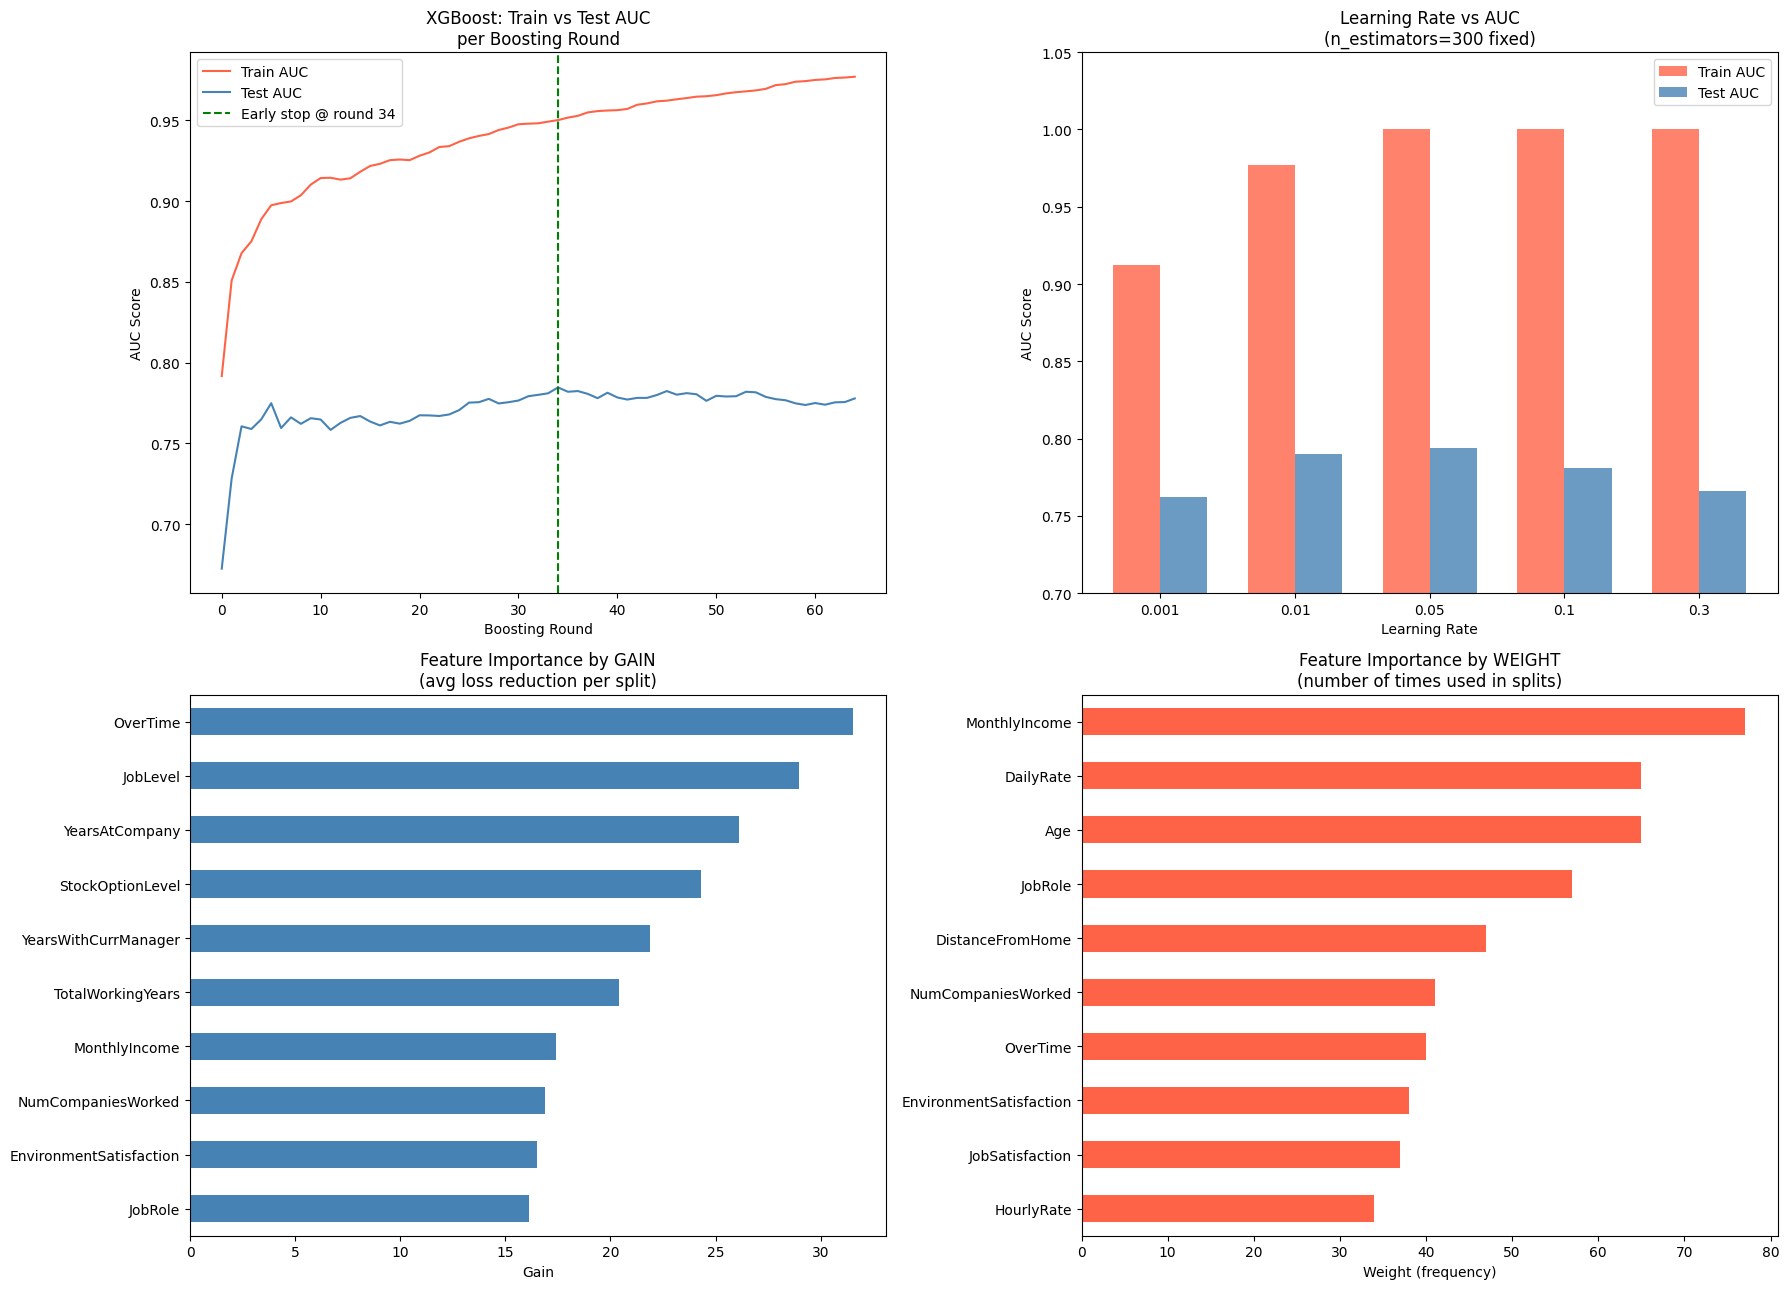

In [ ]:
# 7. Plots 
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Plot 1: Boosting rounds — train vs test AUC over time
axes[0,0].plot(train_aucs, color="tomato",    lw=1.5, label="Train AUC")
axes[0,0].plot(test_aucs,  color="steelblue", lw=1.5, label="Test AUC")
axes[0,0].axvline(best_round, color="green", linestyle="--",
                  label=f"Early stop @ round {best_round}")
axes[0,0].set_xlabel("Boosting Round")
axes[0,0].set_ylabel("AUC Score")
axes[0,0].set_title("XGBoost: Train vs Test AUC\nper Boosting Round")
axes[0,0].legend()

# Plot 2: Learning rate comparison
lr_labels      = [str(lr) for lr in lr_values]
lr_train_aucs  = [lr_results[lr]["train"] for lr in lr_values]
lr_test_aucs   = [lr_results[lr]["test"]  for lr in lr_values]
x = np.arange(len(lr_values))
width = 0.35
axes[0,1].bar(x - width/2, lr_train_aucs, width, color="tomato",    alpha=0.8, label="Train AUC")
axes[0,1].bar(x + width/2, lr_test_aucs,  width, color="steelblue", alpha=0.8, label="Test AUC")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(lr_labels)
axes[0,1].set_xlabel("Learning Rate")
axes[0,1].set_ylabel("AUC Score")
axes[0,1].set_title("Learning Rate vs AUC\n(n_estimators=300 fixed)")
axes[0,1].legend()
axes[0,1].set_ylim(0.7, 1.05)

# Plot 3: Feature importance — gain vs weight
imp_gain_plot   = imp_gain_series.head(10).sort_values()
imp_weight_plot = imp_weight_series.head(10).sort_values()
imp_gain_plot.plot(kind="barh",   ax=axes[1,0], color="steelblue")
axes[1,0].set_title("Feature Importance by GAIN\n(avg loss reduction per split)")
axes[1,0].set_xlabel("Gain")

imp_weight_plot.plot(kind="barh", ax=axes[1,1], color="tomato")
axes[1,1].set_title("Feature Importance by WEIGHT\n(number of times used in splits)")
axes[1,1].set_xlabel("Weight (frequency)")

plt.tight_layout()
plt.show()